### Outlier (Z-Score method)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

dataset = pd.read_csv("../../datasets/loan_dataset.csv", encoding='latin1')

dataset.head(5)

,Loan_ID,Gender,Married,Dependend,Education,Self_Employment,Application,Coapplication,LoanAmount,Credit_History,Property_Area,Loan_status
0,LP1001,NaN,No,3+,Graduate,Yes,5745.07,1889.39,155.91,NaN,Rural,N
1,LP1002,Male,Yes,3+,Not Grad,Yes,7284.54,1812.68,120.63,NaN,Semiurban,Y
2,LP1003,Female,Yes,1,Not Grad,No,7368.82,2613.95,111.22,0.0,Urban,Y
3,LP1004,NaN,Yes,1,Not Grad,NaN,5813.84,1629.27,111.37,0.0,Urban,Y
4,LP1005,Female,Yes,NaN,Not Grad,NaN,5362.94,469.38,61.00,0.0,Rural,N


In [2]:
dataset.isnull().sum()

Loan_ID              0
Gender             374
Married            322
Dependend          195
Education            0
Self_Employment    346
Application          0
Coapplication        0
LoanAmount           0
Credit_History     367
Property_Area        0
Loan_status          0
dtype: int64

In [3]:
dataset.describe()

,Application,Coapplication,LoanAmount,Credit_History
count,1050.000000,1050.000000,1050.000000,683.000000
mean,5069.622105,1989.238019,131.754886,0.500732
std,1465.792703,804.566146,39.103538,0.500366
min,589.420000,-593.010000,9.220000,0.000000
25%,4113.652500,1447.732500,105.817500,0.000000
50%,5085.245000,1980.090000,131.575000,1.000000
75%,5976.737500,2532.972500,157.157500,1.000000
max,10889.360000,4554.490000,284.110000,1.000000


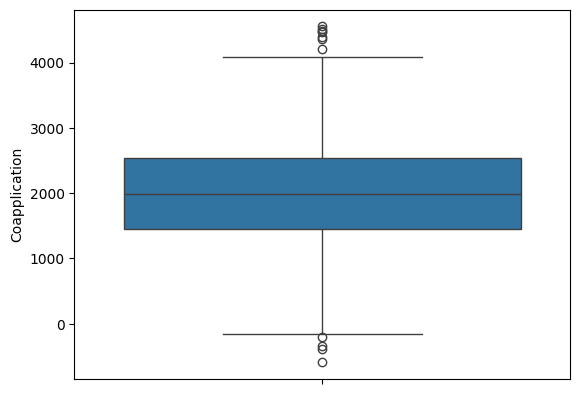

In [4]:
sns.boxplot(dataset["Coapplication"])
plt.show()

First we will try with directly method

In [5]:
min_range = dataset["Coapplication"].mean() - (3*dataset["Coapplication"].std())
max_range = dataset["Coapplication"].mean() + (3*dataset["Coapplication"].std())

In [6]:
min_range, max_range

(np.float64(-424.4604182880562), np.float64(4402.936456383295))

In [7]:
new_data = dataset[dataset["Coapplication"]<=max_range]

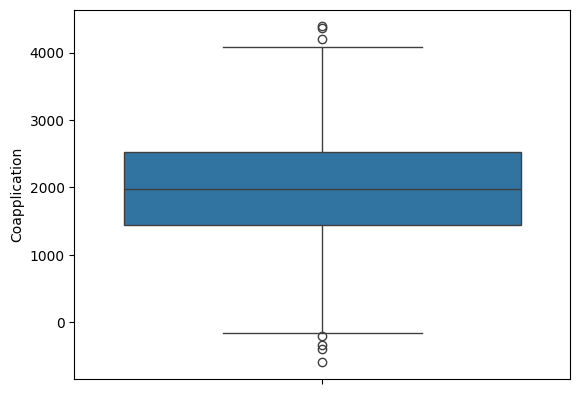

In [8]:
sns.boxplot(new_data["Coapplication"])
plt.show()

we will find z-score value 

In [9]:
z_score = (dataset["Coapplication"] - dataset["Coapplication"].mean())/(dataset["Coapplication"].std())

In [10]:
z_score

0      -0.124102
1      -0.219445
2       0.776458
3      -0.447406
4      -1.889040
          ...   
1045    0.959526
1046   -0.252742
1047   -0.085161
1048    0.480758
1049   -0.096658
Name: Coapplication, Length: 1050, dtype: float64

In [11]:
dataset["z_score"] = z_score

In [12]:
dataset[dataset["z_score"]<3]

,Loan_ID,Gender,Married,Dependend,Education,Self_Employment,Application,Coapplication,LoanAmount,Credit_History,Property_Area,Loan_status,z_score
0,LP1001,NaN,No,3+,Graduate,Yes,5745.07,1889.39,155.91,NaN,Rural,N,-0.124102
1,LP1002,Male,Yes,3+,Not Grad,Yes,7284.54,1812.68,120.63,NaN,Semiurban,Y,-0.219445
2,LP1003,Female,Yes,1,Not Grad,No,7368.82,2613.95,111.22,0.0,Urban,Y,0.776458
3,LP1004,NaN,Yes,1,Not Grad,NaN,5813.84,1629.27,111.37,0.0,Urban,Y,-0.447406
4,LP1005,Female,Yes,NaN,Not Grad,NaN,5362.94,469.38,61.00,0.0,Rural,N,-1.889040
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,LP2046,Male,NaN,3+,Graduate,Yes,5664.50,2761.24,89.15,NaN,Semiurban,N,0.959526
1046,LP2047,Male,No,0,Not Grad,No,5710.21,1785.89,163.87,1.0,Rural,N,-0.252742
1047,LP2048,NaN,NaN,2,Graduate,Yes,1809.16,1920.72,105.89,0.0,Semiurban,N,-0.085161
1048,LP2049,Male,Yes,1,Graduate,NaN,5648.39,2376.04,101.69,1.0,Semiurban,N,0.480758


In [13]:
dataset[dataset["z_score"]<3].shape

(1046, 13)